In [2]:
from datetime import datetime, timedelta
from opendrift.models.oceandrift import OceanDrift
from opendrift.readers.reader_netCDF_CF_generic import Reader
import datetime as dt
import copernicusmarine
import numpy as np
from numpy import random
import pandas as pd

CARTOPY CACHE DIR  /users/smartin/.local/share/cartopy


In [13]:
ds = copernicusmarine.open_dataset(dataset_id='cmems_mod_bal_phy_my_P1D-m', chunk_size_limit=0)
reader_cmems = Reader(ds, name='CMEMS Baltic')

#csv file with the locations of the future turbines
path = '/projappl/project_2018610/data/Wind_farm_position/'
all_region = 'Bothnian_sea_future_turbine_positions_consistent.csv' #1925 turbines
region1 = 'Region1_Bothnian_sea_future_turbine_positions_consistent.csv'#250 turbines
csvfile = path + region1

df = pd.read_csv(csvfile,delimiter=',')
lat = df['1']; lon = df['0']

year = 2017
nb_t = 250 #Number of turbines, depends on the csv file 
nb_p = 10 #Number of particles at each seeding place
nb = nb_t * nb_p #Total number of particles
#z = random.uniform(-10, -2, nb_t)
#z = -np.linspace(0, 5, nb_t)
z = -5

tstep = 30 # calculation time step, in minutes
PD = None     # maximum pelagic propagule duration, in days; not used if None
output_tstep = 60.0 # output time step, in minutes
Kh = 0      # horisontal diffusivity, in m2/s
Kv = 0  # vertical diffusivity, in m2/s
dtmix = 5.0 # vertical mixing timestep, in seconds

o = OceanDrift(loglevel=50)
o.add_reader(reader_cmems, variables=['x_sea_water_velocity', 'y_sea_water_velocity'])

# Configuration settings to modify in wind farm connectivity simulations:

# calculation time step and output time step
o.set_config('general:time_step_minutes', tstep)
o.set_config('general:time_step_output_minutes', output_tstep)

# using auto landmask; if set False, need to provide landmask file
o.set_config('general:use_auto_landmask',True)
# set coastline action, 'previous' or 'stranding'
o.set_config('general:coastline_action', 'stranding')
# if particles get seeded on land, move them to the closest location in sea
o.set_config('seed:ocean_only', True)

# choosing advection scheme, using runge-kutta or runge-kutta 4
o.set_config('drift:advection_scheme', 'runge-kutta4')

# no vertical advection because no vertical velocity components
o.set_config('drift:vertical_advection', False)

# adding horizontal and vertical diffusivities if > 0
if Kh>0:
    o.set_config('drift:horizontal_diffusivity', Kh)
if Kv>0:
    o.set_config('drift:vertical_mixing', True)
    o.set_config('vertical_mixing:timestep', dtmix)  # seconds                                                                                                                                                                                          
    o.set_config('vertical_mixing:diffusivitymodel', 'constant')
    o.set_config('environment:fallback:ocean_vertical_diffusivity',Kv)

# no stokes drift or wind effects; we might want to change these later
o.set_config('drift:stokes_drift', False)
o.set_config('drift:wind_drift_depth', 0.0)
o.set_config('seed:wind_drift_factor', None)

# setting maximum pelagic duration for particles
if PD is not None:
    o.set_config('drift:max_age_seconds',PD*24*3600)

starttime = dt.datetime(year,6,1)
o.seed_elements(lon=lon, lat=lat, z=z, number=nb, radius=100, time=starttime) 

INFO - 2026-04-15T12:14:59Z - Selected dataset version: "202303"
INFO - 2026-04-15T12:14:59Z - Selected dataset part: "default"


In [11]:
nb_days = 7
name_file = 'test_seeding_' + str(nb) + '_' + str(nb_days) + 'days' + '_region_1_' + str(year)
o.run(duration=timedelta(days=nb_days), outfile=name_file)

<xarray.Dataset> Size: 37MB
Dimensions:                              (trajectory: 2500, time: 169)
Coordinates:
  * trajectory                           (trajectory) int32 10kB 0 1 ... 2499
  * time                                 (time) datetime64[ns] 1kB 2017-06-01...
Data variables: (12/19)
    status                               (trajectory, time) float64 3MB ...
    moving                               (trajectory, time) float64 3MB ...
    age_seconds                          (trajectory, time) float32 2MB ...
    origin_marker                        (trajectory, time) float64 3MB ...
    lon                                  (trajectory, time) float32 2MB ...
    lat                                  (trajectory, time) float32 2MB ...
    ...                                   ...
    x_wind                               (trajectory, time) float32 2MB ...
    y_wind                               (trajectory, time) float32 2MB ...
    horizontal_diffusivity               (trajectory, time) float32 2MB ...
    sea_surface_wave_significant_height  (trajectory, time) float32 2MB ...
    sea_floor_depth_below_sea_level      (trajectory, time) float32 2MB ...
    land_binary_mask                     (trajectory, time) float32 2MB ...
Attributes: (12/118)
    Conventions:                                                           CF...
    standard_name_vocabulary:                                              CF...
    featureType:                                                           tr...
    title:                                                                 Op...
    summary:                                                               Ou...
    keywords:                                                              tr...
    ...                                                                    ...
    geospatial_lon_units:                                                  de...
    geospatial_lon_resolution:                                             point
    runtime:                                                               0:...
    geospatial_vertical_min:                                               -5.0
    geospatial_vertical_max:                                               -5.0
    geospatial_vertical_positive:                                          up

(<GeoAxes: title={'center': 'OpenDrift - OceanDrift\n2017-06-01 00:00 to 2017-06-08 00:00 UTC (169 steps)'}>,
 <Figure size 705.363x1100 with 1 Axes>)

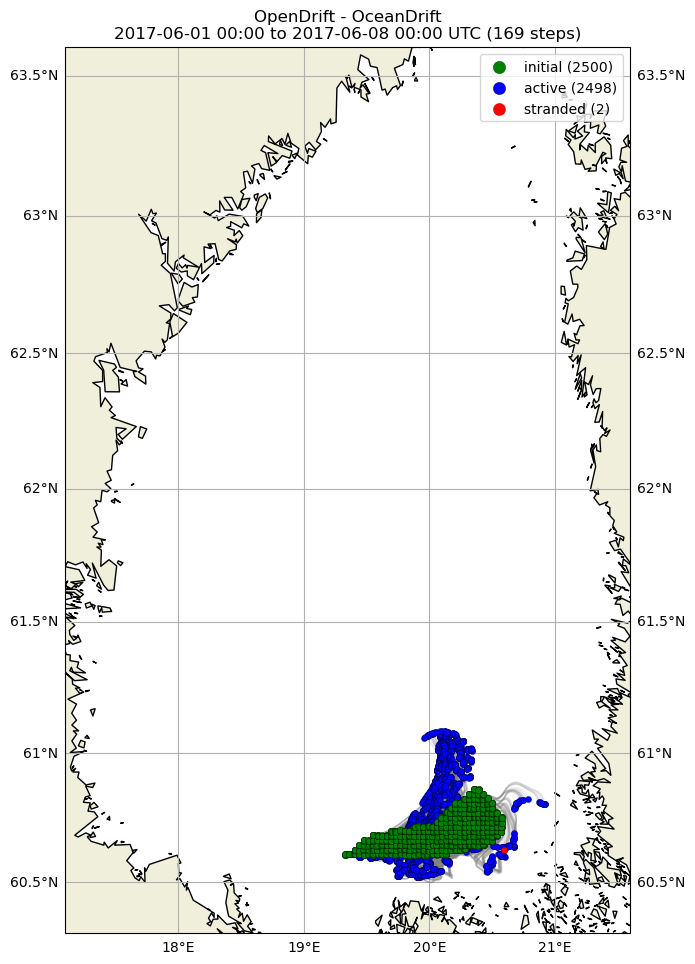

In [12]:
o.plot(filename=name_file, corners=[17.1,21.6,60.3,63.6])